In [1]:
import numpy as np
import pandas as pd
import os 
from scipy.stats import expon, uniform, beta
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from time import time
from copy import deepcopy
from itertools import product
from functools import partial
import networkx as nx
from sklearn.metrics import mean_absolute_error

from InfluenceDiffusion.Graph import Graph
from InfluenceDiffusion.influence_models import LTM
from InfluenceDiffusion.estimation_models.OptimEstimation import GLTWeightEstimator
from InfluenceDiffusion.weight_samplers import make_random_weights_with_indeg_constraint, \
    make_random_weights_with_fixed_indeg
from InfluenceDiffusion.plot_utils import plot_with_conf_intervals

os.chdir("/Users/amkagan/Desktop/gltm_experiments")

from utils.trace_utils import trace_train_test_split, make_report_traces
from utils.utils import plot_distribution, RMAE, make_distrib_name
from utils.model_evaluation_utils import compare_metric_over_bins, make_heatmap

## Generate graph & traces

In [2]:
n_nodes = 100
rewire_p = 0.2
init_k = 10

random_state = 1

g = nx.watts_strogatz_graph(n_nodes, k=init_k, p=rewire_p, seed=random_state)
g = Graph(g.edges)

true_weights = make_random_weights_with_indeg_constraint(g, random_state=random_state)
g.set_weights(true_weights)

Avg number of activated nodes: 29.69. Std: 20.82


100%|███████████████████████████| 1000/1000 [00:05<00:00, 167.80it/s]


Proportion of edges participated in <= 5 traces: 0.0


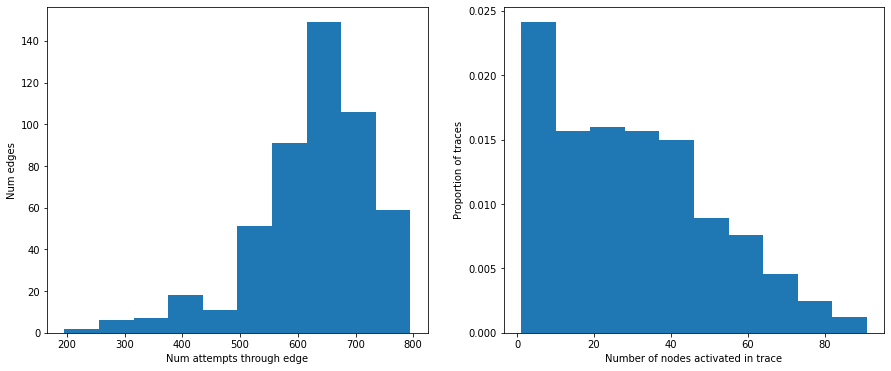

(750, 250)

In [13]:
n_traces = 1000
max_seed_size = 20
test_ratio = 0.25
seed_size_range=range(1, max_seed_size + 1)

true_distrib = beta(2, 2)
true_ltm = LTM(g, threshold_generator=true_distrib, random_state=random_state)
traces = true_ltm.sample_traces(n_traces=n_traces, seed_size_range=seed_size_range)
_ = make_report_traces(traces)

train_traces, test_traces = trace_train_test_split(traces, test_ratio=test_ratio)
test_seeds = [test_trace[0] for test_trace in test_traces]
len(train_traces), len(test_traces)

## Estimate weights and spread

In [14]:
distribs = [true_distrib, beta(1, 1), beta(2, 1), beta(1, 2)]
distrib_names = [make_distrib_name(distrib) for distrib in distribs]

distrib_name_2_weights = {}
for distrib_name, distrib in zip(distrib_names, distribs):
    estimator = GLTWeightEstimator(g, vertex_2_distrib=distrib, n_jobs=8)
    pred_weights = estimator.fit(train_traces).weights_
    distrib_name_2_weights[distrib_name] = pred_weights

In [15]:
num_runs_per_seed = 1000

def compute_avg_spread_over_seeds(distrib, weights, seeds, g, 
                                  num_runs_per_seed=num_runs_per_seed, with_std=False, n_jobs=None):
    g_copy = deepcopy(g)
    g_copy.set_weights(weights)
    model = LTM(g_copy, threshold_generator=distrib, check_init=True, n_jobs=n_jobs)
    results = [model.estimate_spread(seed, n_runs=num_runs_per_seed, with_std=with_std) 
               for seed in tqdm(seeds, position=0)]
    return np.stack(results)

In [16]:
true_test_spread = compute_avg_spread_over_seeds(distrib=true_distrib, weights=true_weights,
                                                 seeds=test_seeds, g=g)

100%|██████████████████████████████| 250/250 [01:00<00:00,  4.12it/s]


In [17]:
distrib_2_pred_spreads = {distrib_name: compute_avg_spread_over_seeds(distrib=distrib, 
                                                                      weights=weights, 
                                                                      seeds=test_seeds, g=g) 
                          for distrib, (distrib_name, weights) in zip(distribs, distrib_name_2_weights.items())}

100%|██████████████████████████████| 250/250 [00:55<00:00,  4.47it/s]


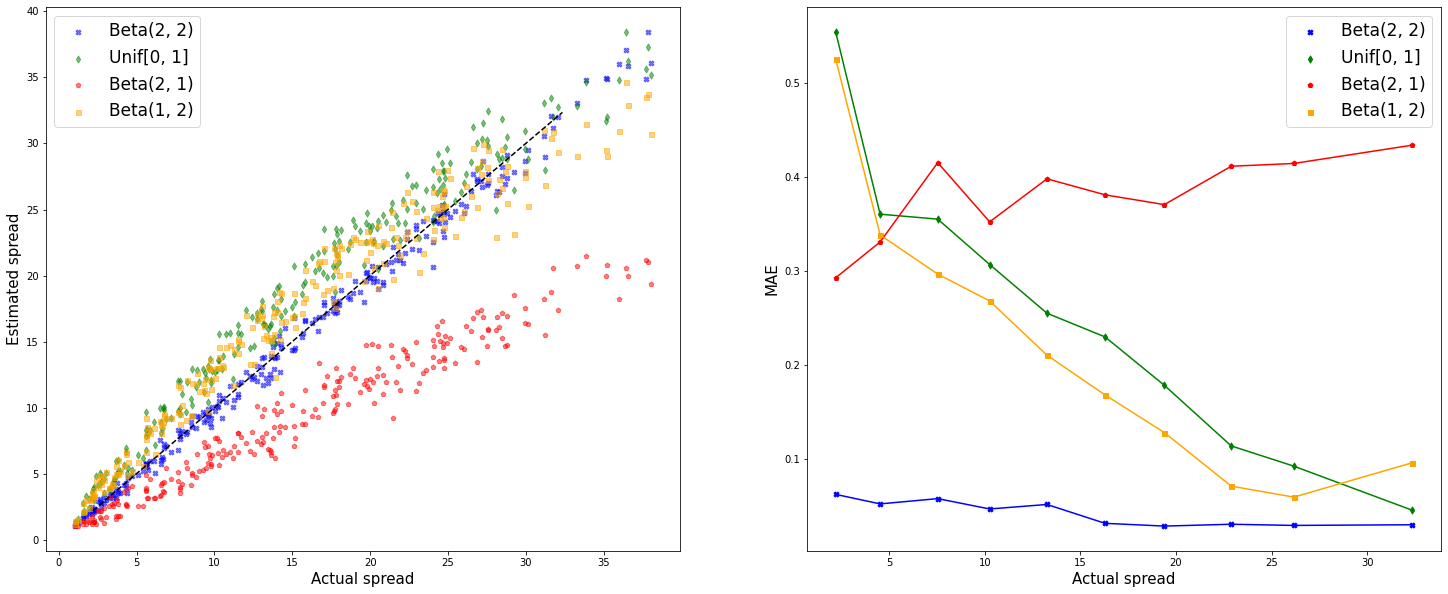

In [9]:
compare_metric_over_bins(true_test_spread, list(distrib_2_pred_spreads.values()), 
                         metric=RMAE,
                         pred_names=distrib_names, bins=10,
                         markersize=25, colors=["b", "g", "r", "orange"])

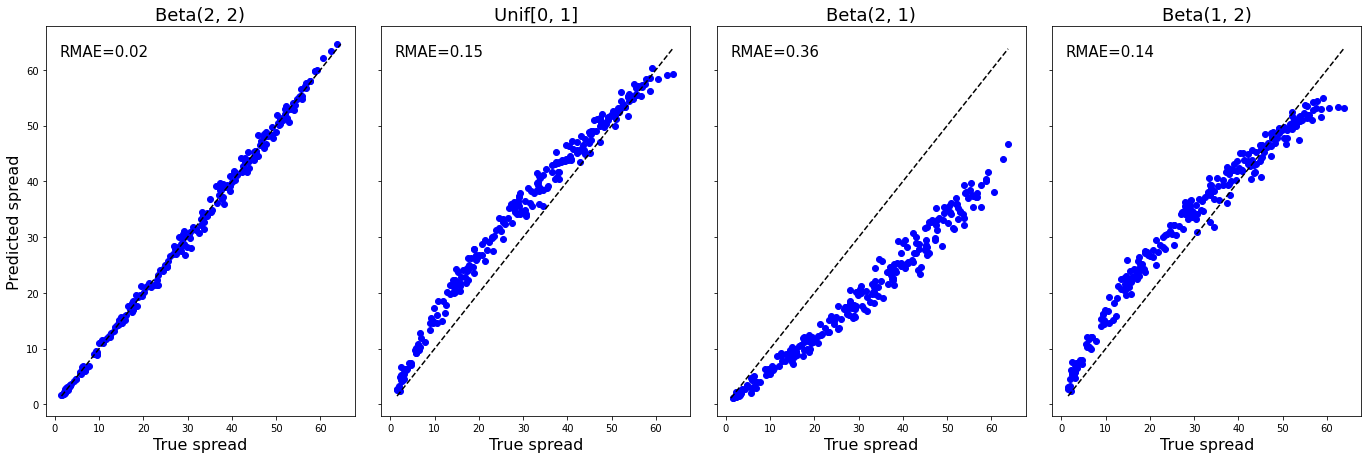

In [20]:
fig, axs = plt.subplots(1, len(distribs), figsize=(19, 6), sharex=True, sharey=True)
fontsize=16
fig.tight_layout(w_pad=1.075)

for i, (ax, distrib_name, distrib) in enumerate(zip(axs, distrib_names, distribs)):
    
    pred_spread = distrib_2_pred_spreads[distrib_name]
    rmae = np.round(RMAE(true_test_spread, pred_spread), 2)
    
    ylab = "Predicted spread" if i == 0 else None
    plot_with_conf_intervals(true_test_spread, pred_spread,
                             ylab=ylab,
                             xlab="True spread",
                             ax=ax, fontsize=fontsize, color="blue")
    ax.set_title(distrib_name, fontsize=fontsize + 2)
    ax.text(1, max(true_test_spread) * 0.98, f"RMAE={rmae}", fontsize=fontsize - 1)

plt.savefig("figures/spread_comparison.pdf", dpi=200, bbox_inches="tight")

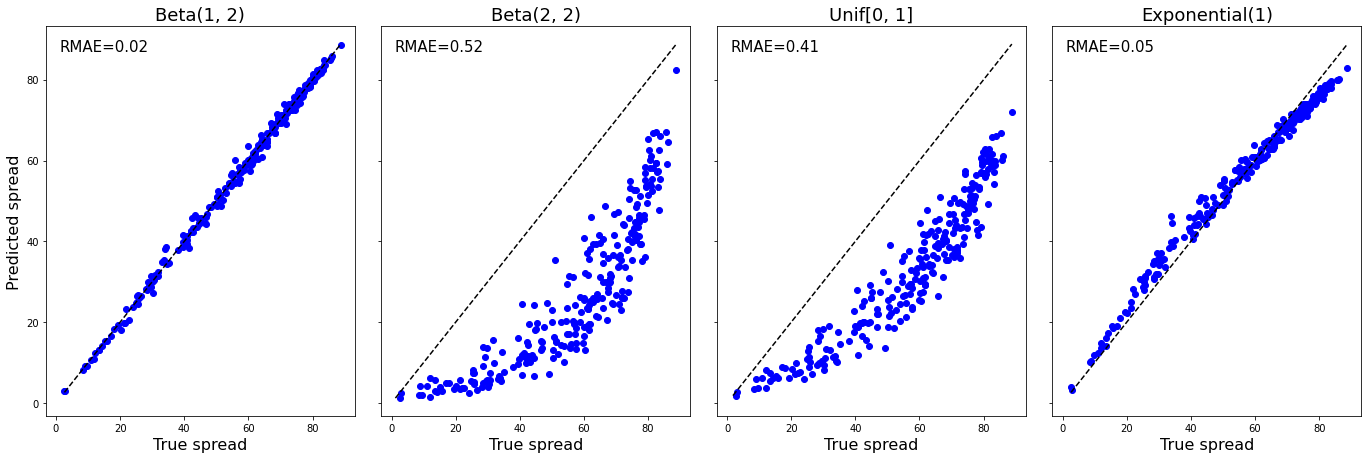

In [88]:
fig, axs = plt.subplots(1, len(distribs), figsize=(19, 6), sharex=True, sharey=True)
fontsize=16
fig.tight_layout(w_pad=1.075)

for i, (ax, distrib_name, distrib) in enumerate(zip(axs, distrib_names, distribs)):
    
    pred_spread = distrib_2_pred_spreads[distrib_name]
    rmae = np.round(RMAE(true_test_spread, pred_spread), 2)
    
    ylab = "Predicted spread" if i == 0 else None
    plot_with_conf_intervals(true_test_spread, pred_spread,
                             ylab=ylab,
                             xlab="True spread",
                             ax=ax, fontsize=fontsize, color="blue")
    ax.set_title(distrib_name, fontsize=fontsize + 2)
    ax.text(1, max(true_test_spread) * 0.98, f"RMAE={rmae}", fontsize=fontsize - 1)

plt.savefig("figures/spread_comparison.pdf", dpi=200, bbox_inches="tight")

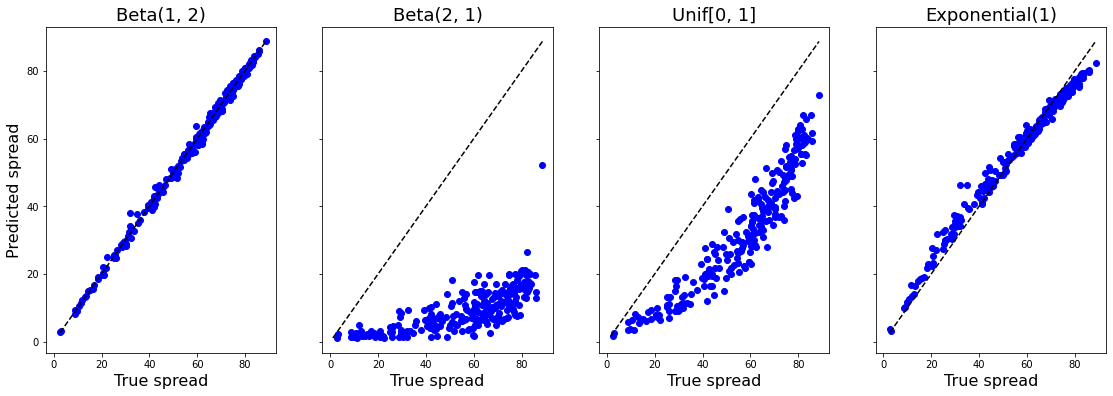

In [54]:
fig, axs = plt.subplots(1, len(distribs), figsize=(19, 6), sharex=True, sharey=True)
fontsize=16


for i, (ax, distrib_name, distrib) in enumerate(zip(axs, distrib_names, distribs)):
    
    pred_spread = distrib_2_pred_spreads[distrib_name]
    rmae = np.round(RMAE(true_test_spread, pred_spread), 2)
    
    ylab = "Predicted spread" if i == 0 else None
    plot_with_conf_intervals(true_test_spread, pred_spread,
                             ylab=ylab,
                             xlab="True spread",
                             ax=ax, fontsize=fontsize, color="blue")
    
#     ax.set_ylim([0, max(true_test_spread)])
    ax.set_title(distrib_name, fontsize=fontsize + 2)
#     ax.set_xticks([0, 5, 10, 15, 20])